In [1]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score

In [2]:
df = pd.read_csv('sleep.csv')

In [3]:
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [4]:
df['Sleep Disorder'] = df['Sleep Disorder'].fillna("doesn't have")
df['Sleep Disorder'].unique()
sleep_dic = {'Insomnia': 0, "doesn't have":1, 'Sleep Apnea':2}
df['Sleep Disorder'] = df['Sleep Disorder'].map(sleep_dic)
Y = df['Sleep Disorder']
df = df.drop('Sleep Disorder', axis=1)
df = df.drop('Person ID', axis=1)
df['Gender'] = df['Gender'].map({"Male":0, "Female":1})
groups = []
for i in range(df['Age'].min() - 1, df['Age'].max() + 5, 5):
    groups.append(i)
groups_cut = pd.cut(df['Age'].values, groups)
df['Age'] = groups_cut.codes

le = LabelEncoder()
le.fit(df['Occupation'].unique())
df['Occupation'] = le.transform(df['Occupation'])
df['Sleep Duration'] = df['Sleep Duration'] * 10
groups = []
for i in range(54, 90, 5):
    groups.append(i)
groups_cut = pd.cut(df['Sleep Duration'].values, groups)
df['Sleep Duration'] = groups_cut.codes
le2 = LabelEncoder()
le2.fit(df['BMI Category'].unique())
df['BMI Category'] = le2.transform(df['BMI Category'])
df[['Systolic', 'Diastolic']] = df['Blood Pressure'].str.split('/', expand=True)
df['Systolic'] = df['Systolic'].astype(int)
df['Diastolic'] = df['Diastolic'].astype(int)
def determine_pressure_status(row):
    systolic = row['Systolic']
    diastolic = row['Diastolic']
    if systolic < 90 or diastolic < 60:
        return -1  # Пониженное давление
    elif systolic > 120 or diastolic > 80:
        return 1   # Повышенное давление
    else:
        return 0   # Нормальное давление
df['PressureStatus'] = df.apply(determine_pressure_status, axis=1)
df = df.drop(['Blood Pressure', 'Systolic', 'Diastolic'], axis=1)
df.head()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,PressureStatus
0,0,0,9,1,6,42,6,3,77,4200,1
1,0,0,1,1,6,60,8,0,75,10000,1
2,0,0,1,1,6,60,8,0,75,10000,1
3,0,0,6,0,4,30,8,2,85,3000,1
4,0,0,6,0,4,30,8,2,85,3000,1


In [5]:
df.isna().sum()

Gender                     0
Age                        0
Occupation                 0
Sleep Duration             0
Quality of Sleep           0
Physical Activity Level    0
Stress Level               0
BMI Category               0
Heart Rate                 0
Daily Steps                0
PressureStatus             0
dtype: int64

In [6]:
x_train, x_test, y_train, y_test = train_test_split(df, Y, test_size = 0.3, random_state=100, stratify=Y)

In [7]:
import shap

### Лог регрессия

In [76]:
from sklearn.model_selection import GridSearchCV
scale_features = ["Physical Activity Level", "Heart Rate", "Daily Steps", "Quality of Sleep", "Sleep Duration"]
preprocessor = ColumnTransformer([
    ('scaler', StandardScaler(), scale_features)
], remainder='passthrough')  # Оставляем остальные признаки без изменений'
param_grid_lr = {
    'classifier__C': [0.01, 0.04, 0.03, 0.1, 1, 10, 100],
    'classifier__max_iter': [5000, 10000, 20000, 1000000]
}
pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=10000, C=0.04))
])
clf = LogisticRegression(random_state=0, max_iter=1000000, C=1)
grid_lr = GridSearchCV(pipeline, param_grid_lr, cv=5, scoring='f1_macro')
clf = grid_lr.fit(x_train, y_train).best_estimator_
clf.fit(x_train, y_train)
test_predict = clf.predict(x_test)

**Глобальная объяснимость**

C:\Users\User\AppData\Local\Temp\ipykernel_18896\2501207914.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values,


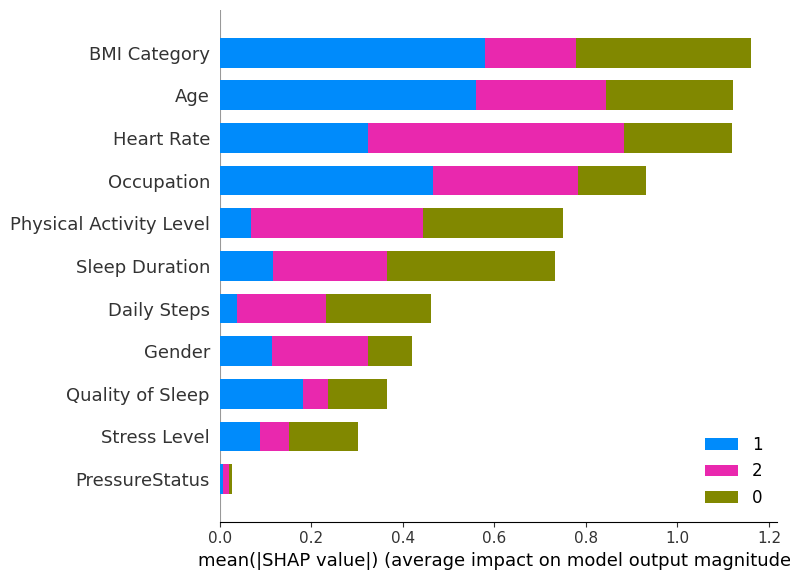

In [77]:
explainer = shap.LinearExplainer(clf.named_steps['classifier'], 
                                clf.named_steps['preprocessing'].transform(x_train))
shap_values = explainer.shap_values(clf.named_steps['preprocessing'].transform(x_test))
shap.summary_plot(shap_values, 
                 clf.named_steps['preprocessing'].transform(x_test), 
                 feature_names=scale_features + [x for x in x_train.columns if x not in scale_features],
                 class_names=clf.named_steps['classifier'].classes_,
                 plot_type="bar")

In [78]:
import numpy as np

In [53]:
x_test.shape

(113, 11)

**Локальная объяснимость**

In [80]:
all_feature_names = scale_features + [x for x in x_train.columns if x not in scale_features]
def shap_plot(idx):
    sample_X = x_test.iloc[idx:idx+1]
    transformed_sample = clf.named_steps['preprocessing'].transform(sample_X)
    predicted_class = clf.predict(sample_X)
    print(predicted_class)
    predicted_class_idx = np.where(clf.named_steps['classifier'].classes_ == predicted_class)[0][0]
    shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[predicted_class_idx][idx], 
        base_values=explainer.expected_value[predicted_class_idx], 
        data=transformed_sample[0], 
        feature_names=all_feature_names
    ),
    max_display=10 
)

[1]


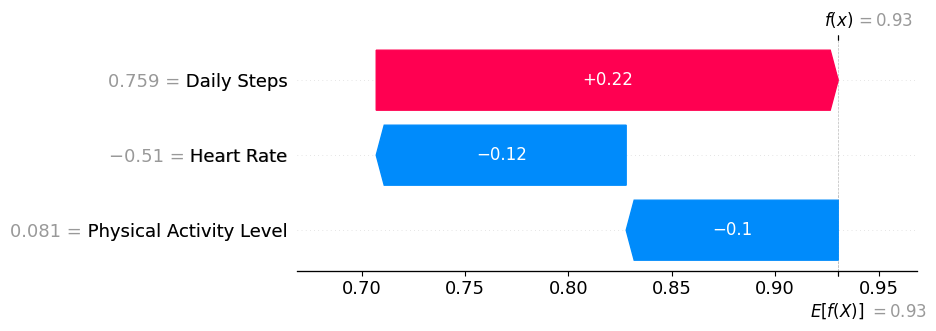

In [81]:
shap_plot(5)

### Случайный лес

In [88]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV

clf = RandomForestClassifier(random_state=100, n_estimators=7, max_features=6)
clf.fit(x_train, y_train)
test_predict = clf.predict(x_test)

C:\Users\User\AppData\Local\Temp\ipykernel_18896\3551126026.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, x_test, plot_type="bar")  # Для важности признаков


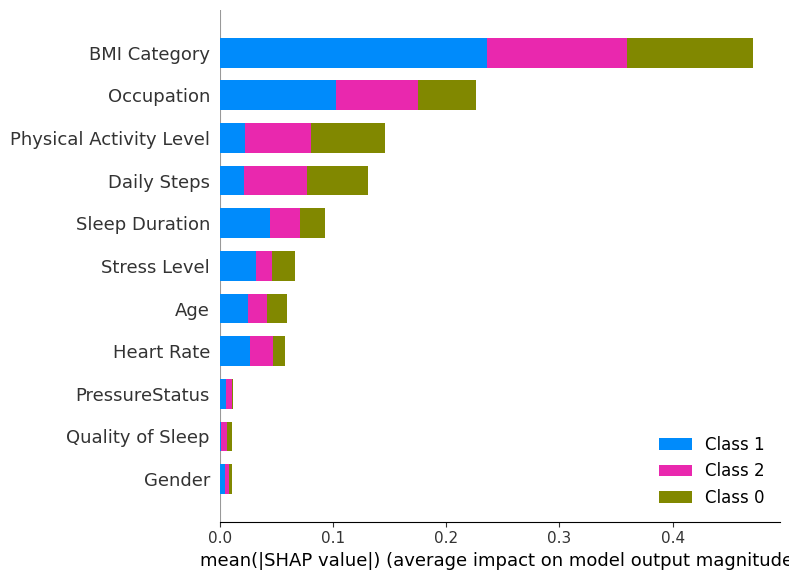

In [92]:
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(x_test)  # можно использовать x_train
shap.summary_plot(shap_values, x_test, plot_type="bar")  # Для важности признаков

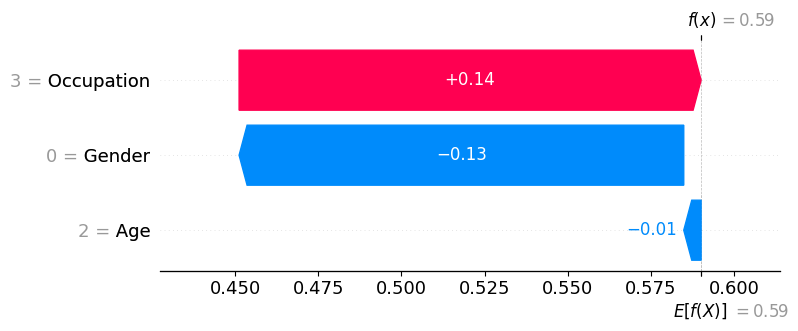

In [96]:
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(x_test)
example_index = 5 
base_value = explainer.expected_value[1]
shap_values_for_example = shap_values[1][example_index]
feature_names = x_test.columns.tolist()
exp = shap.Explanation(
    values=shap_values_for_example,
    base_values=base_value,
    data=x_test.iloc[example_index].values,
    feature_names=feature_names
)
shap.plots.waterfall(exp, max_display=10)

### Бустинг

In [101]:
from sklearn.ensemble import GradientBoostingClassifier

param_grid = {
    'n_estimators': [10, 20, 50, 100],
    'learning_rate': [0.01, 0.05, 1, 0.2],
    'max_depth': [3, 5, 7, 10]
}

clf = GradientBoostingClassifier()
grid_search = GridSearchCV(estimator=clf, param_grid=param_grid, 
                           cv=5, scoring='f1_macro', n_jobs=-1)
grid_search.fit(x_train, y_train)
best_boost = grid_search.best_estimator_
best_boost.fit(x_train, y_train)
test_predict = best_boost.predict(x_test)

Using 261 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/113 [00:00<?, ?it/s]

C:\Users\User\AppData\Local\Temp\ipykernel_18896\2468966233.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, x_test , plot_type="bar")


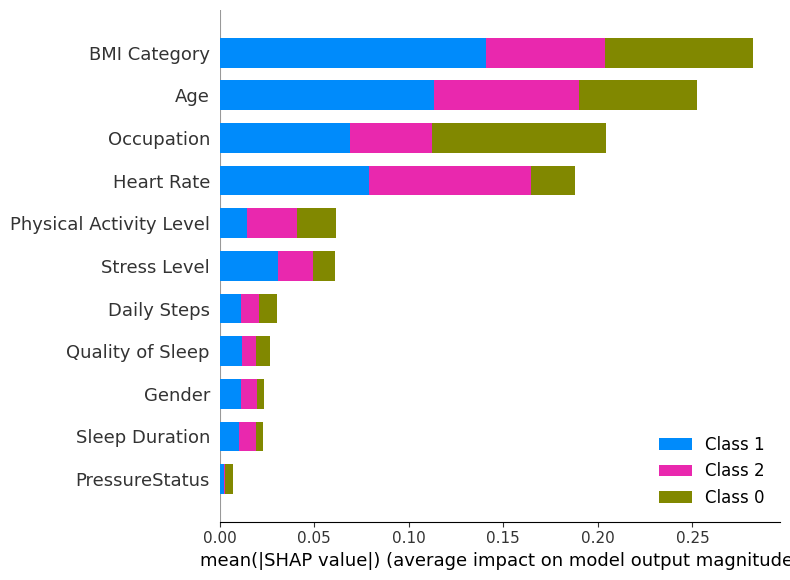

In [108]:
explainer = shap.KernelExplainer(best_boost.predict_proba, shap.sample(x_train, 1000))
shap_values = explainer.shap_values(x_test)  
shap.summary_plot(shap_values, x_test , plot_type="bar")

  0%|          | 0/113 [00:00<?, ?it/s]

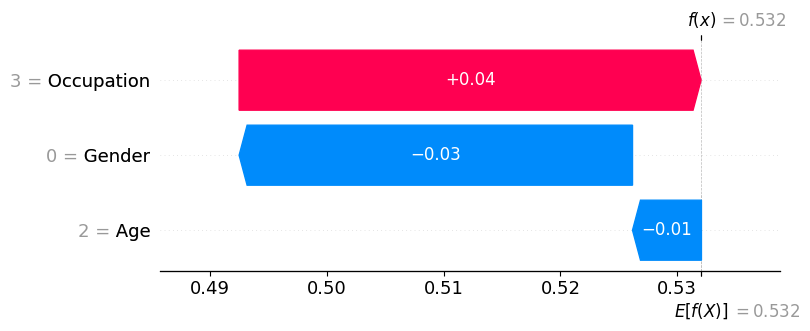

Предсказанный класс: 1


In [120]:
background = shap.sample(x_train, 100)  # Уменьшим размер для скорости
explainer = shap.KernelExplainer(best_boost.predict_proba, background)
shap_values = explainer.shap_values(x_test)
def shap_plot_gb(idx, model=best_boost, x_data=x_test):
    sample = x_data.iloc[[idx]]
    predicted = model.predict(sample)[0]
    class_idx = list(model.classes_).index(predicted)
    
    shap.plots.waterfall(
        shap.Explanation(
            values=shap_values[class_idx][idx],
            base_values=explainer.expected_value[class_idx],
            data=sample.iloc[0].values,
            feature_names=x_data.columns.tolist()
        )
    )
    
    print(f"Предсказанный класс: {predicted}") 
shap_plot_gb(5) 